# Titanic Model Combine

In [83]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TARGET_COLUMN = "Survived"
DROP_COLUMNS = ["PassengerId", "Name", "Ticket", "Cabin"]

Kích thước dữ liệu huấn luyện: (891, 12)
Kích thước dữ liệu kiểm tra: (418, 11)
Kích thước dữ liệu tổng hợp: (1309, 11)
          Số lượng thiếu  Phần trăm (%)
Cabin               1014      77.463713
Age                  263      20.091673
Embarked               2       0.152788
Fare                   1       0.076394


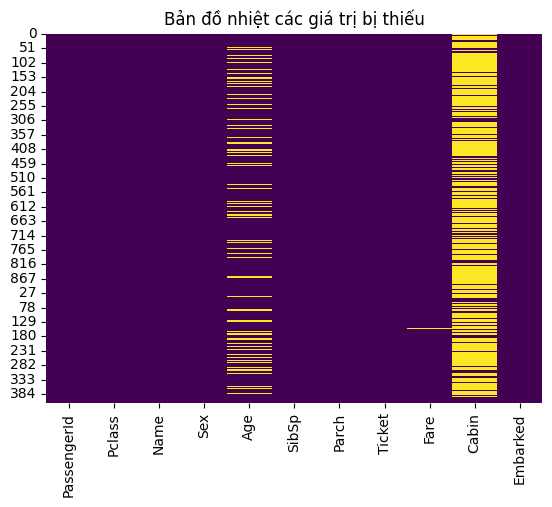

Giá trị điền cho 'Embarked' (mode): 'S'
Giá trị điền cho 'Fare' (median): 14.4542
Giá trị điền cho 'Age' (median): 28.0

Đã điền các giá trị thiếu cho Embarked, Fare, và Age.
Đã tạo cột 'HasCabin' và xóa cột 'Cabin'.

Số lượng giá trị thiếu còn lại:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64
Đã tạo các đặc trưng 'FamilySize' và 'IsAlone'.
Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Major         2
Mlle          2
Ms            2
Mme           1
Don           1
Sir           1
Lady          1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

Danh xưng sau khi đã được nhóm lại:
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       33
Don         1
Name: count, dtype: int64
Đã tạo các đặc trưng 'AgeBin'

,Pclass,Sex,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Don,Title_Master,...,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,AgeBin_4,FareBin_0,FareBin_1,FareBin_2,FareBin_3,Survived
0,3,0,0,2,0,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,0
1,1,1,1,2,0,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,1
2,3,1,0,1,1,False,False,True,False,False,...,False,True,False,False,False,False,True,False,False,1
3,1,1,1,2,0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,1
4,3,0,0,1,1,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,0



5 dòng đầu của tập test đã xử lý:


,Pclass,Sex,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Don,Title_Master,...,Title_Rare,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,AgeBin_4,FareBin_0,FareBin_1,FareBin_2,FareBin_3
0,3,0,0,1,1,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,3,1,0,2,0,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
2,2,0,0,1,1,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,3,0,0,1,1,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
4,3,1,0,3,0,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False


Đã nạp thành công dữ liệu train_final/test_final từ Feature.ipynb


In [84]:
# Chạy lại notebook Feature để tạo dữ liệu đã tiền xử lý
from IPython import get_ipython

feature_notebook = Path.cwd().parent / "Feature" / "Feature.ipynb"
if not feature_notebook.exists():
    raise FileNotFoundError("Không tìm thấy notebook Feature đã tiền xử lý dữ liệu")

get_ipython().run_line_magic("run", str(feature_notebook))
print("Đã nạp thành công dữ liệu train_final/test_final từ Feature.ipynb")

In [85]:
# Chuẩn bị tập train đã qua feature engineering
if "train_final" not in globals() or "test_final" not in globals():
    raise NameError("train_final/test_final chưa sẵn sàng, hãy bảo đảm cell chạy Feature đã thực thi")

bool_cols = train_final.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    train_final[bool_cols] = train_final[bool_cols].astype(int)
    test_final[bool_cols] = test_final[bool_cols].astype(int)

X = train_final.drop(columns=[TARGET_COLUMN])
y = train_final[TARGET_COLUMN]
print(f"Kích thước tập train_final: {train_final.shape}")

Kích thước tập train_final: (891, 24)


In [86]:
# Tách danh sách đặc trưng số và danh sách đặc trưng phân loại để xử lý riêng
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['Pclass', 'Sex', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Don', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_0', 'AgeBin_1', 'AgeBin_2', 'AgeBin_3', 'AgeBin_4', 'FareBin_0', 'FareBin_1', 'FareBin_2', 'FareBin_3']
Categorical features: []


In [87]:
# Xây dựng bộ tiền xử lý: chuẩn hóa số liệu và mã hóa biến phân loại
transformers = []

if numeric_features:
    transformers.append(
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    )

if categorical_features:
    transformers.append(
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        )
    )

if not transformers:
    raise ValueError("No features available after preprocessing")

preprocessor = ColumnTransformer(transformers=transformers)
print("Preprocessor configured.")

Preprocessor configured.


In [88]:
# Chuẩn bị danh sách đối tượng tìm kiếm siêu tham số để tinh chỉnh từng mô hình
searches = []
print("Initialized search container.")

Initialized search container.


In [89]:
# Tinh chỉnh Logistic Regression theo penalty và hệ số điều chuẩn
logistic_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1000, solver="liblinear")),
        ]
    ),
    param_grid={
        "model__C": [0.1, 1.0, 10.0, 50.0],
        "model__penalty": ["l1", "l2"],
    },
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
)
logistic_entry = ("logistic_regression", logistic_search)
searches.append(logistic_entry)
print("Configured logistic_regression search.")

Configured logistic_regression search.


In [90]:
# Tinh chỉnh Random Forest về số cây, độ sâu và điều kiện chia
random_forest_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
        ]
    ),
    param_grid={
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 6, 10, 14],
        "model__min_samples_split": [2, 5, 10],
    },
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
)
random_forest_entry = ("random_forest", random_forest_search)
searches.append(random_forest_entry)
print("Configured random_forest search.")

Configured random_forest search.


In [91]:
# Tinh chỉnh SVC bằng RandomizedSearch trên kernel và tham số điều chuẩn
svc_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", SVC(probability=True, random_state=RANDOM_STATE)),
        ]
    ),
    param_distributions={
        "model__C": list(np.logspace(-2, 2, 20)),
        "model__kernel": ["rbf", "poly", "sigmoid", "linear"],
        "model__gamma": ["scale", "auto"],
    },
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
    random_state=RANDOM_STATE,
)
svc_entry = ("svc", svc_search)
searches.append(svc_entry)
print("Configured svc search.")

Configured svc search.



In [92]:
# Tinh chỉnh KNN theo số lượng láng giềng và thước đo khoảng cách
knn_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", KNeighborsClassifier()),
        ]
    ),
    param_distributions={
        "model__n_neighbors": list(range(3, 22, 2)),
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    n_iter=15,
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
    random_state=RANDOM_STATE,
)
knn_entry = ("knn", knn_search)
searches.append(knn_entry)
print("Configured knn search.")

Configured knn search.


In [93]:
# Tinh chỉnh Extra Trees về quy mô rừng và độ sâu tối đa
extra_trees_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", ExtraTreesClassifier(random_state=RANDOM_STATE)),
        ]
    ),
    param_grid={
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_split": [2, 5, 10],
    },
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
)
extra_trees_entry = ("extra_trees", extra_trees_search)
searches.append(extra_trees_entry)
print("Configured extra_trees search.")

Configured extra_trees search.


In [94]:
# Tinh chỉnh AdaBoost về tốc độ học và số lượng bộ phân loại yếu
ada_boost_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", AdaBoostClassifier(random_state=RANDOM_STATE)),
        ]
    ),
    param_grid={
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": [0.5, 1.0, 1.5],
    },
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
)
ada_boost_entry = ("ada_boost", ada_boost_search)
searches.append(ada_boost_entry)
print("Configured ada_boost search.")

Configured ada_boost search.


In [95]:
# Tinh chỉnh Gradient Boosting để khám phá độ sâu cây và hệ số shrinkage
gradient_boosting_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]
    ),
    param_distributions={
        "model__n_estimators": [150, 250, 350, 450],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.8, 1.0],
        "model__min_samples_split": [2, 5, 10],
    },
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
    random_state=RANDOM_STATE,
)
gradient_boosting_entry = ("gradient_boosting", gradient_boosting_search)
searches.append(gradient_boosting_entry)
print("Configured gradient_boosting search.")

Configured gradient_boosting search.


In [96]:
# Chia dữ liệu thành tập huấn luyện và tập kiểm định giữ ngoài để chọn mô hình
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training size: {X_train.shape}, validation size: {X_valid.shape}")

results = []

Training size: (712, 23), validation size: (179, 23)



In [97]:
# Huấn luyện và đánh giá Logistic Regression sau khi tìm kiếm tham số
name, search = logistic_entry
print(f"Running search for {name}...")
search.fit(X_train, y_train)
best_estimator = search.best_estimator_
validation_predictions = best_estimator.predict(X_valid)
val_accuracy = accuracy_score(y_valid, validation_predictions)
results.append(
    {
        "name": name,
        "search": search,
        "best_estimator": best_estimator,
        "cv_accuracy": search.best_score_,
        "validation_accuracy": val_accuracy,
        "best_params": search.best_params_,
    }
)
print(
    f"{name}: best CV accuracy={search.best_score_:.4f}, validation accuracy={val_accuracy:.4f}"
)
print(f"Best params: {search.best_params_}")

Running search for logistic_regression...
logistic_regression: best CV accuracy=0.8160, validation accuracy=0.8380
Best params: {'model__C': 0.1, 'model__penalty': 'l2'}
logistic_regression: best CV accuracy=0.8160, validation accuracy=0.8380
Best params: {'model__C': 0.1, 'model__penalty': 'l2'}


In [98]:
# Huấn luyện và đánh giá Random Forest sau khi tinh chỉnh
name, search = random_forest_entry
print(f"Running search for {name}...")
search.fit(X_train, y_train)
best_estimator = search.best_estimator_
validation_predictions = best_estimator.predict(X_valid)
val_accuracy = accuracy_score(y_valid, validation_predictions)
results.append(
    {
        "name": name,
        "search": search,
        "best_estimator": best_estimator,
        "cv_accuracy": search.best_score_,
        "validation_accuracy": val_accuracy,
        "best_params": search.best_params_,
    }
)
print(
    f"{name}: best CV accuracy={search.best_score_:.4f}, validation accuracy={val_accuracy:.4f}"
)
print(f"Best params: {search.best_params_}")

Running search for random_forest...
random_forest: best CV accuracy=0.8259, validation accuracy=0.8101
Best params: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 600}


In [99]:
# Huấn luyện và đánh giá SVC sau khi tinh chỉnh
name, search = svc_entry
print(f"Running search for {name}...")
search.fit(X_train, y_train)
best_estimator = search.best_estimator_
validation_predictions = best_estimator.predict(X_valid)
val_accuracy = accuracy_score(y_valid, validation_predictions)
results.append(
    {
        "name": name,
        "search": search,
        "best_estimator": best_estimator,
        "cv_accuracy": search.best_score_,
        "validation_accuracy": val_accuracy,
        "best_params": search.best_params_,
    }
)
print(
    f"{name}: best CV accuracy={search.best_score_:.4f}, validation accuracy={val_accuracy:.4f}"
)
print(f"Best params: {search.best_params_}")

Running search for svc...
svc: best CV accuracy=0.8259, validation accuracy=0.8268
Best params: {'model__kernel': 'linear', 'model__gamma': 'auto', 'model__C': np.float64(0.18329807108324356)}
svc: best CV accuracy=0.8259, validation accuracy=0.8268
Best params: {'model__kernel': 'linear', 'model__gamma': 'auto', 'model__C': np.float64(0.18329807108324356)}


In [100]:
# Huấn luyện và đánh giá KNN sau khi tinh chỉnh
name, search = knn_entry
print(f"Running search for {name}...")
search.fit(X_train, y_train)
best_estimator = search.best_estimator_
validation_predictions = best_estimator.predict(X_valid)
val_accuracy = accuracy_score(y_valid, validation_predictions)
results.append(
    {
        "name": name,
        "search": search,
        "best_estimator": best_estimator,
        "cv_accuracy": search.best_score_,
        "validation_accuracy": val_accuracy,
        "best_params": search.best_params_,
    }
)
print(
    f"{name}: best CV accuracy={search.best_score_:.4f}, validation accuracy={val_accuracy:.4f}"
)
print(f"Best params: {search.best_params_}")

Running search for knn...
knn: best CV accuracy=0.8118, validation accuracy=0.7765
Best params: {'model__weights': 'distance', 'model__p': 2, 'model__n_neighbors': 17}
knn: best CV accuracy=0.8118, validation accuracy=0.7765
Best params: {'model__weights': 'distance', 'model__p': 2, 'model__n_neighbors': 17}


In [101]:
# Huấn luyện và đánh giá Extra Trees sau khi tinh chỉnh
name, search = extra_trees_entry
print(f"Running search for {name}...")
search.fit(X_train, y_train)
best_estimator = search.best_estimator_
validation_predictions = best_estimator.predict(X_valid)
val_accuracy = accuracy_score(y_valid, validation_predictions)
results.append(
    {
        "name": name,
        "search": search,
        "best_estimator": best_estimator,
        "cv_accuracy": search.best_score_,
        "validation_accuracy": val_accuracy,
        "best_params": search.best_params_,
    }
)
print(
    f"{name}: best CV accuracy={search.best_score_:.4f}, validation accuracy={val_accuracy:.4f}"
)
print(f"Best params: {search.best_params_}")

Running search for extra_trees...
extra_trees: best CV accuracy=0.8245, validation accuracy=0.8045
Best params: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 300}
extra_trees: best CV accuracy=0.8245, validation accuracy=0.8045
Best params: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 300}


In [102]:
# Huấn luyện và đánh giá AdaBoost sau khi tinh chỉnh
name, search = ada_boost_entry
print(f"Running search for {name}...")
search.fit(X_train, y_train)
best_estimator = search.best_estimator_
validation_predictions = best_estimator.predict(X_valid)
val_accuracy = accuracy_score(y_valid, validation_predictions)
results.append(
    {
        "name": name,
        "search": search,
        "best_estimator": best_estimator,
        "cv_accuracy": search.best_score_,
        "validation_accuracy": val_accuracy,
        "best_params": search.best_params_,
    }
)
print(
    f"{name}: best CV accuracy={search.best_score_:.4f}, validation accuracy={val_accuracy:.4f}"
)
print(f"Best params: {search.best_params_}")

Running search for ada_boost...


ada_boost: best CV accuracy=0.8189, validation accuracy=0.8324
Best params: {'model__learning_rate': 0.5, 'model__n_estimators': 400}


In [103]:
# Huấn luyện và đánh giá Gradient Boosting sau khi tinh chỉnh
name, search = gradient_boosting_entry
print(f"Running search for {name}...")
search.fit(X_train, y_train)
best_estimator = search.best_estimator_
validation_predictions = best_estimator.predict(X_valid)
val_accuracy = accuracy_score(y_valid, validation_predictions)
results.append(
    {
        "name": name,
        "search": search,
        "best_estimator": best_estimator,
        "cv_accuracy": search.best_score_,
        "validation_accuracy": val_accuracy,
        "best_params": search.best_params_,
    }
)
print(
    f"{name}: best CV accuracy={search.best_score_:.4f}, validation accuracy={val_accuracy:.4f}"
)
print(f"Best params: {search.best_params_}")

Running search for gradient_boosting...
gradient_boosting: best CV accuracy=0.8273, validation accuracy=0.8156
Best params: {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05}
gradient_boosting: best CV accuracy=0.8273, validation accuracy=0.8156
Best params: {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05}


                  name  cv_accuracy  validation_accuracy
0  logistic_regression     0.816015             0.837989
5            ada_boost     0.818861             0.832402
2                  svc     0.825864             0.826816
6    gradient_boosting     0.827263             0.815642
1        random_forest     0.825874             0.810056
4          extra_trees     0.824456             0.804469
3                  knn     0.811799             0.776536


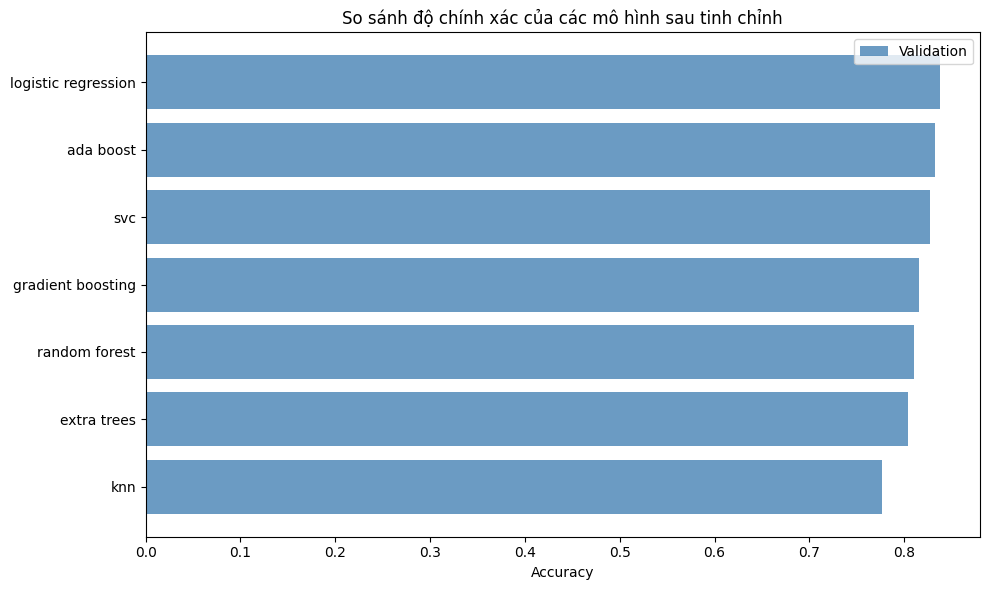

In [106]:
# Trực quan hóa độ chính xác CV và validation cho tất cả các mô hình
results_df = pd.DataFrame(results)
if results_df.empty:
    raise ValueError("Chưa có kết quả để vẽ, hãy chạy lại các cell huấn luyện mô hình trước")

results_df = results_df.sort_values(by="validation_accuracy", ascending=False)
print(results_df[["name", "cv_accuracy", "validation_accuracy"]])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bar_positions = range(len(results_df))
plt.barh(bar_positions, results_df["validation_accuracy"], color="steelblue", alpha=0.8, label="Validation")
#plt.barh(bar_positions, results_df["cv_accuracy"], color="orange", alpha=0.6, label="CV Mean")
plt.yticks(bar_positions, results_df["name"].str.replace("_", " "))
plt.xlabel("Accuracy")
plt.title("So sánh độ chính xác của các mô hình sau tinh chỉnh")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [104]:
# Chọn mô hình tốt nhất theo tập validation và trình bày chẩn đoán chi tiết
if not results:
    raise RuntimeError("No models were evaluated")

best_result = max(results, key=lambda item: item["validation_accuracy"])
best_name = best_result["name"]
best_estimator = best_result["best_estimator"]

final_predictions = best_estimator.predict(X_valid)
final_accuracy = accuracy_score(y_valid, final_predictions)
final_confusion = confusion_matrix(y_valid, final_predictions)
final_report = classification_report(y_valid, final_predictions, zero_division=0)

print(f"\n=== Final Evaluation: {best_name} ===")
print(f"Validation accuracy: {final_accuracy:.4f}")
print("Confusion matrix:")
print(final_confusion)
print("Classification report:")
print(final_report)


=== Final Evaluation: logistic_regression ===
Validation accuracy: 0.8380
Confusion matrix:
[[95 15]
 [14 55]]
Classification report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       110
           1       0.79      0.80      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



## Đánh giá hiệu suất cuối cùng
- Mô hình tốt nhất sau tinh chỉnh là `logistic_regression`, đạt accuracy **0.8380** trên tập validation (179 mẫu).
- Ma trận nhầm lẫn: [[95, 15], [14, 55]]. Mô hình giữ được recall 0.86 với lớp không sống sót và 0.80 với lớp sống sót, cân bằng khá tốt giữa hai lớp.
- Precision lớp sống sót đạt 0.79, F1-score 0.79; macro F1 chung khoảng 0.83, cho thấy mô hình tuyến tính sau khi tối ưu hoạt động ổn định trên dữ liệu đã feature.
- Có thể xem xét tuning thêm hoặc bổ sung trọng số lớp nếu cần nâng recall cho hành khách sống sót hơn nữa, nhưng kết quả hiện tại đã vượt baseline ban đầu.